<a href="https://colab.research.google.com/github/JotJaw/data-science-bootcamp/blob/main/02_analiza_danych/02_dane_gieldowe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

print(f'numpy version: {np.__version__}')
print(f'pandas version: {pd.__version__}')

numpy version: 2.0.2
pandas version: 2.2.2


#Załadowanie danych

In [3]:
def fetch_financial_data(company='AMZN'):
  """Pobiera dane dotyczące notowań spółek na giełdzie według symboli
  z seriwsu stooq.pl"""
  import pandas_datareader.data as web
  return web.DataReader(name=company, data_source='stooq')

df = fetch_financial_data()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2026-03-09 to 2021-03-11
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1254 non-null   float64
 1   High    1254 non-null   float64
 2   Low     1254 non-null   float64
 3   Close   1254 non-null   float64
 4   Volume  1254 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [4]:
df #jako indeks data sesji giełdowej - mogą być przerwy weekendowe;
#cena otwarcia, najwyższa, najniższa w ciągu dnia, oraz cena zamknięcia; Volume - wartość wlumenu, ile papieru obróciło się podczas danej sesji giełdowej

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-09,210.450,213.820,207.110,213.420,54642926
2026-03-06,214.990,217.320,212.530,213.120,51152716
2026-03-05,215.980,220.470,215.590,218.860,60943447
2026-03-04,210.470,217.540,210.150,216.820,54731101
2026-03-03,203.100,209.178,202.480,208.630,43184918
...,...,...,...,...,...
2021-03-17,153.661,158.652,153.511,156.786,62371680
2021-03-16,155.248,156.445,153.793,154.593,50775280
2021-03-15,153.728,154.112,151.604,154.084,58371840


In [5]:
df.head() #bez prarametru - 5 pierwszych wierszy, z parametrem - tyle, ile chcemy

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-09,210.45,213.820,207.11,213.42,54642926
2026-03-06,214.99,217.320,212.53,213.12,51152716
2026-03-05,215.98,220.470,215.59,218.86,60943447
2026-03-04,210.47,217.540,210.15,216.82,54731101
2026-03-03,203.10,209.178,202.48,208.63,43184918


In [6]:
df.tail() #5 ostatnich

,Open,High,Low,Close,Volume
Date,,,,,
2021-03-17,153.661,158.652,153.511,156.786,62371680
2021-03-16,155.248,156.445,153.793,154.593,50775280
2021-03-15,153.728,154.112,151.604,154.084,58371840
2021-03-12,153.750,154.949,152.275,154.474,48437760
2021-03-11,155.200,156.589,154.146,155.680,55527820


In [7]:
df.head(3)

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-09,210.45,213.82,207.11,213.42,54642926
2026-03-06,214.99,217.32,212.53,213.12,51152716
2026-03-05,215.98,220.47,215.59,218.86,60943447


In [8]:
df.tail(1)

,Open,High,Low,Close,Volume
Date,,,,,
2021-03-11,155.2,156.589,154.146,155.68,55527820


In [9]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [10]:
df.columns = [col.lower() for col in df.columns] #zmiana nazw kolumn w df
df.head()

,open,high,low,close,volume
Date,,,,,
2026-03-09,210.45,213.820,207.11,213.42,54642926
2026-03-06,214.99,217.320,212.53,213.12,51152716
2026-03-05,215.98,220.470,215.59,218.86,60943447
2026-03-04,210.47,217.540,210.15,216.82,54731101
2026-03-03,203.10,209.178,202.48,208.63,43184918


In [11]:
df.describe()

,open,high,low,close,volume
count,1254.000000,1254.000000,1254.000000,1254.000000,1.254000e+03
mean,165.737951,167.693010,163.638199,165.714443,5.681407e+07
std,42.062213,42.222512,41.761580,42.003770,2.703882e+07
min,82.800000,83.480000,81.430000,81.820000,1.142054e+07
25%,131.997500,133.600000,130.443750,131.932500,3.953774e+07
50%,167.860500,169.749000,166.310000,168.631000,5.080720e+07
75%,194.661250,197.245000,192.285000,194.527500,6.636190e+07
max,255.360000,258.600000,252.900000,254.000000,2.726617e+08


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
open,1254.0,1.657380e+02,4.206221e+01,82.80,1.319975e+02,1.678605e+02,1.946612e+02,2.553600e+02
high,1254.0,1.676930e+02,4.222251e+01,83.48,1.336000e+02,1.697490e+02,1.972450e+02,2.586000e+02
low,1254.0,1.636382e+02,4.176158e+01,81.43,1.304438e+02,1.663100e+02,1.922850e+02,2.529000e+02
close,1254.0,1.657144e+02,4.200377e+01,81.82,1.319325e+02,1.686310e+02,1.945275e+02,2.540000e+02
volume,1254.0,5.681407e+07,2.703882e+07,11420543.00,3.953774e+07,5.080720e+07,6.636190e+07,2.726617e+08


#Selekca kolumn

In [13]:
df = df.head(10)
df

,open,high,low,close,volume
Date,,,,,
2026-03-09,210.45,213.820,207.110,213.42,54642926
2026-03-06,214.99,217.320,212.530,213.12,51152716
2026-03-05,215.98,220.470,215.590,218.86,60943447
2026-03-04,210.47,217.540,210.150,216.82,54731101
2026-03-03,203.10,209.178,202.480,208.63,43184918
2026-03-02,204.55,209.730,203.460,208.39,46001010
2026-02-27,206.83,210.330,205.200,210.00,57191213
2026-02-26,210.73,211.050,205.345,207.92,47531800
2026-02-25,210.46,211.590,208.930,210.64,41346400


In [14]:
df['open']

,open
Date,
2026-03-09,210.45
2026-03-06,214.99
2026-03-05,215.98
2026-03-04,210.47
2026-03-03,203.10
2026-03-02,204.55
2026-02-27,206.83
2026-02-26,210.73
2026-02-25,210.46


In [15]:
df.open

,open
Date,
2026-03-09,210.45
2026-03-06,214.99
2026-03-05,215.98
2026-03-04,210.47
2026-03-03,203.10
2026-03-02,204.55
2026-02-27,206.83
2026-02-26,210.73
2026-02-25,210.46


In [16]:
df[['open']] #przekazane jako lista kolumn - wycięte jako df

,open
Date,
2026-03-09,210.45
2026-03-06,214.99
2026-03-05,215.98
2026-03-04,210.47
2026-03-03,203.10
2026-03-02,204.55
2026-02-27,206.83
2026-02-26,210.73
2026-02-25,210.46


In [17]:
df[['open','close']]

,open,close
Date,,
2026-03-09,210.45,213.42
2026-03-06,214.99,213.12
2026-03-05,215.98,218.86
2026-03-04,210.47,216.82
2026-03-03,203.10,208.63
2026-03-02,204.55,208.39
2026-02-27,206.83,210.00
2026-02-26,210.73,207.92
2026-02-25,210.46,210.64


In [18]:
df.iloc[:,0]

,open
Date,
2026-03-09,210.45
2026-03-06,214.99
2026-03-05,215.98
2026-03-04,210.47
2026-03-03,203.10
2026-03-02,204.55
2026-02-27,206.83
2026-02-26,210.73
2026-02-25,210.46


In [19]:
df.iloc[:,0:3]

,open,high,low
Date,,,
2026-03-09,210.45,213.820,207.110
2026-03-06,214.99,217.320,212.530
2026-03-05,215.98,220.470,215.590
2026-03-04,210.47,217.540,210.150
2026-03-03,203.10,209.178,202.480
2026-03-02,204.55,209.730,203.460
2026-02-27,206.83,210.330,205.200
2026-02-26,210.73,211.050,205.345
2026-02-25,210.46,211.590,208.930


In [20]:
df.iloc[:,3:5]

,close,volume
Date,,
2026-03-09,213.42,54642926
2026-03-06,213.12,51152716
2026-03-05,218.86,60943447
2026-03-04,216.82,54731101
2026-03-03,208.63,43184918
2026-03-02,208.39,46001010
2026-02-27,210.00,57191213
2026-02-26,207.92,47531800
2026-02-25,210.64,41346400


In [21]:
df.iloc[:,-1]

,volume
Date,
2026-03-09,54642926
2026-03-06,51152716
2026-03-05,60943447
2026-03-04,54731101
2026-03-03,43184918
2026-03-02,46001010
2026-02-27,57191213
2026-02-26,47531800
2026-02-25,41346400


In [22]:
df.iloc[:,[-1]]

,volume
Date,
2026-03-09,54642926
2026-03-06,51152716
2026-03-05,60943447
2026-03-04,54731101
2026-03-03,43184918
2026-03-02,46001010
2026-02-27,57191213
2026-02-26,47531800
2026-02-25,41346400


In [23]:
df.iloc[:-3]

,open,high,low,close,volume
Date,,,,,
2026-03-09,210.45,213.820,207.11,213.42,54642926
2026-03-06,214.99,217.320,212.53,213.12,51152716
2026-03-05,215.98,220.470,215.59,218.86,60943447
2026-03-04,210.47,217.540,210.15,216.82,54731101
2026-03-03,203.10,209.178,202.48,208.63,43184918
2026-03-02,204.55,209.730,203.46,208.39,46001010
2026-02-27,206.83,210.330,205.20,210.00,57191213


#Selekcja wierszy

In [24]:
df

,open,high,low,close,volume
Date,,,,,
2026-03-09,210.45,213.820,207.110,213.42,54642926
2026-03-06,214.99,217.320,212.530,213.12,51152716
2026-03-05,215.98,220.470,215.590,218.86,60943447
2026-03-04,210.47,217.540,210.150,216.82,54731101
2026-03-03,203.10,209.178,202.480,208.63,43184918
2026-03-02,204.55,209.730,203.460,208.39,46001010
2026-02-27,206.83,210.330,205.200,210.00,57191213
2026-02-26,210.73,211.050,205.345,207.92,47531800
2026-02-25,210.46,211.590,208.930,210.64,41346400


In [25]:
df.iloc[0]

,2026-03-09
open,210.45
high,213.82
low,207.11
close,213.42
volume,54642926.00


In [26]:
df.iloc[:3]

,open,high,low,close,volume
Date,,,,,
2026-03-09,210.45,213.82,207.11,213.42,54642926
2026-03-06,214.99,217.32,212.53,213.12,51152716
2026-03-05,215.98,220.47,215.59,218.86,60943447


In [27]:
df.loc[['2026-03-03']]

,open,high,low,close,volume
Date,,,,,
2026-03-03,203.1,209.178,202.48,208.63,43184918


In [28]:
df.loc['2026-03-03']

,2026-03-03
open,2.031000e+02
high,2.091780e+02
low,2.024800e+02
close,2.086300e+02
volume,4.318492e+07


In [29]:
df.loc[['2026-03-03','2026-03-04']]


,open,high,low,close,volume
Date,,,,,
2026-03-03,203.10,209.178,202.48,208.63,43184918
2026-03-04,210.47,217.540,210.15,216.82,54731101


In [30]:
df

,open,high,low,close,volume
Date,,,,,
2026-03-09,210.45,213.820,207.110,213.42,54642926
2026-03-06,214.99,217.320,212.530,213.12,51152716
2026-03-05,215.98,220.470,215.590,218.86,60943447
2026-03-04,210.47,217.540,210.150,216.82,54731101
2026-03-03,203.10,209.178,202.480,208.63,43184918
2026-03-02,204.55,209.730,203.460,208.39,46001010
2026-02-27,206.83,210.330,205.200,210.00,57191213
2026-02-26,210.73,211.050,205.345,207.92,47531800
2026-02-25,210.46,211.590,208.930,210.64,41346400


In [31]:
df.sort_index(inplace=True)

/tmp/ipykernel_169/1763084551.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_index(inplace=True)


In [32]:
df

,open,high,low,close,volume
Date,,,,,
2026-02-24,205.47,210.360,203.250,208.56,41137200
2026-02-25,210.46,211.590,208.930,210.64,41346400
2026-02-26,210.73,211.050,205.345,207.92,47531800
2026-02-27,206.83,210.330,205.200,210.00,57191213
2026-03-02,204.55,209.730,203.460,208.39,46001010
2026-03-03,203.10,209.178,202.480,208.63,43184918
2026-03-04,210.47,217.540,210.150,216.82,54731101
2026-03-05,215.98,220.470,215.590,218.86,60943447
2026-03-06,214.99,217.320,212.530,213.12,51152716


In [33]:
df.loc['2026-03-02':'2026-03-10']

,open,high,low,close,volume
Date,,,,,
2026-03-02,204.55,209.730,203.46,208.39,46001010
2026-03-03,203.10,209.178,202.48,208.63,43184918
2026-03-04,210.47,217.540,210.15,216.82,54731101
2026-03-05,215.98,220.470,215.59,218.86,60943447
2026-03-06,214.99,217.320,212.53,213.12,51152716
2026-03-09,210.45,213.820,207.11,213.42,54642926


#Obliczanie nowych kolumn

In [34]:
df = fetch_financial_data('UBER')
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2026-03-09 to 2021-03-11
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1254 non-null   float64
 1   High    1254 non-null   float64
 2   Low     1254 non-null   float64
 3   Close   1254 non-null   float64
 4   Volume  1254 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [35]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-09,74.17,74.540,71.940,73.84,21208861
2026-03-06,74.73,75.570,74.190,75.13,14771234
2026-03-05,76.59,78.250,75.135,75.44,17893964
2026-03-04,75.87,77.040,75.013,76.65,19818516
2026-03-03,74.50,77.305,74.020,76.36,21892515


In [36]:
df.describe() #czy są braki

,Open,High,Low,Close,Volume
count,1254.000000,1254.000000,1254.000000,1254.000000,1.254000e+03
mean,55.850865,56.774363,54.901963,55.842249,2.343554e+07
std,21.881676,22.075822,21.619597,21.854289,1.608937e+07
min,20.370000,21.125500,19.895000,20.460000,4.310663e+06
25%,36.637500,37.585000,35.590000,36.710000,1.540215e+07
50%,50.940000,51.630000,50.230000,50.810000,1.983204e+07
75%,73.683750,74.811250,72.535000,73.822500,2.730426e+07
max,100.130000,101.990000,98.585000,100.100000,3.642612e+08


In [37]:
df.head(3)

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-09,74.17,74.54,71.940,73.84,21208861
2026-03-06,74.73,75.57,74.190,75.13,14771234
2026-03-05,76.59,78.25,75.135,75.44,17893964


In [38]:
df['Average'] = (df.Open + df.Close) / 2.0
df.head()

,Open,High,Low,Close,Volume,Average
Date,,,,,,
2026-03-09,74.17,74.540,71.940,73.84,21208861,74.005
2026-03-06,74.73,75.570,74.190,75.13,14771234,74.930
2026-03-05,76.59,78.250,75.135,75.44,17893964,76.015
2026-03-04,75.87,77.040,75.013,76.65,19818516,76.260
2026-03-03,74.50,77.305,74.020,76.36,21892515,75.430


In [39]:
df = df.sort_index()
df.head()

,Open,High,Low,Close,Volume,Average
Date,,,,,,
2021-03-11,58.80,59.48,58.22,58.95,17293752,58.875
2021-03-12,58.97,60.59,57.62,60.35,14839307,59.660
2021-03-15,60.35,60.53,59.12,60.19,14993629,60.270
2021-03-16,59.99,61.02,58.38,58.85,12885725,59.420
2021-03-17,57.07,57.57,55.54,56.36,25509926,56.715


In [40]:
df[['Close']].shift(1)

,Close
Date,
2021-03-11,NaN
2021-03-12,58.95
2021-03-15,60.35
2021-03-16,60.19
2021-03-17,58.85
...,...
2026-03-03,75.95
2026-03-04,76.36
2026-03-05,76.65


In [41]:
df['Close_shift'] = df[['Close']].shift(1)
df.head()

,Open,High,Low,Close,Volume,Average,Close_shift
Date,,,,,,,
2021-03-11,58.80,59.48,58.22,58.95,17293752,58.875,NaN
2021-03-12,58.97,60.59,57.62,60.35,14839307,59.660,58.95
2021-03-15,60.35,60.53,59.12,60.19,14993629,60.270,60.35
2021-03-16,59.99,61.02,58.38,58.85,12885725,59.420,60.19
2021-03-17,57.07,57.57,55.54,56.36,25509926,56.715,58.85


In [42]:
df.Close / df.Close_shift - 1 #dzienna zamiana wyrażona w procentach

,0
Date,
2021-03-11,NaN
2021-03-12,0.023749
2021-03-15,-0.002651
2021-03-16,-0.022263
2021-03-17,-0.042311
...,...
2026-03-03,0.005398
2026-03-04,0.003798
2026-03-05,-0.015786


In [43]:
df['Daily_Change'] = df.Close / df.Close_shift - 1
df.head()

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2021-03-11,58.80,59.48,58.22,58.95,17293752,58.875,NaN,NaN
2021-03-12,58.97,60.59,57.62,60.35,14839307,59.660,58.95,0.023749
2021-03-15,60.35,60.53,59.12,60.19,14993629,60.270,60.35,-0.002651
2021-03-16,59.99,61.02,58.38,58.85,12885725,59.420,60.19,-0.022263
2021-03-17,57.07,57.57,55.54,56.36,25509926,56.715,58.85,-0.042311


In [44]:
df['Daily Change'] = df.Close / df.Close_shift - 1
df.head()

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change,Daily Change
Date,,,,,,,,,
2021-03-11,58.80,59.48,58.22,58.95,17293752,58.875,NaN,NaN,NaN
2021-03-12,58.97,60.59,57.62,60.35,14839307,59.660,58.95,0.023749,0.023749
2021-03-15,60.35,60.53,59.12,60.19,14993629,60.270,60.35,-0.002651,-0.002651
2021-03-16,59.99,61.02,58.38,58.85,12885725,59.420,60.19,-0.022263,-0.022263
2021-03-17,57.07,57.57,55.54,56.36,25509926,56.715,58.85,-0.042311,-0.042311


In [45]:
del df['Daily Change']
df.head()

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2021-03-11,58.80,59.48,58.22,58.95,17293752,58.875,NaN,NaN
2021-03-12,58.97,60.59,57.62,60.35,14839307,59.660,58.95,0.023749
2021-03-15,60.35,60.53,59.12,60.19,14993629,60.270,60.35,-0.002651
2021-03-16,59.99,61.02,58.38,58.85,12885725,59.420,60.19,-0.022263
2021-03-17,57.07,57.57,55.54,56.36,25509926,56.715,58.85,-0.042311


In [46]:
df.Daily_Change.min()

-0.11584196394322976

In [47]:
df.Daily_Change.max()

0.18902439024390238

<Axes: >

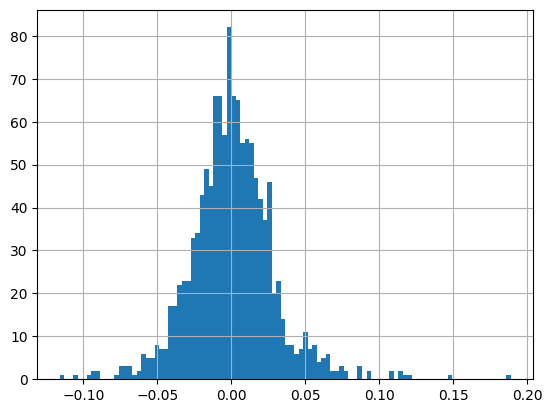

In [48]:
  df.Daily_Change.hist(bins=100) #histogram stopy zwrotu

<Axes: >

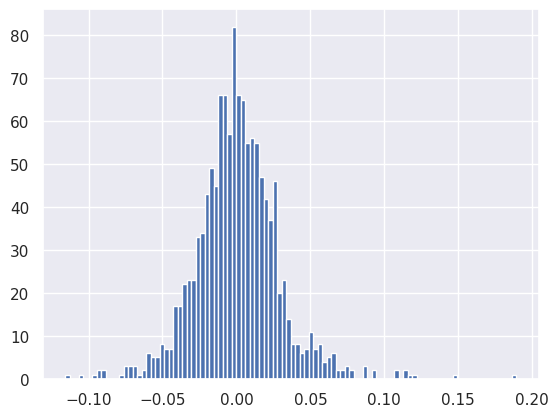

In [49]:
import seaborn as sns
sns.set()

df.Daily_Change.hist(bins=100)
#

<Axes: xlabel='Date'>

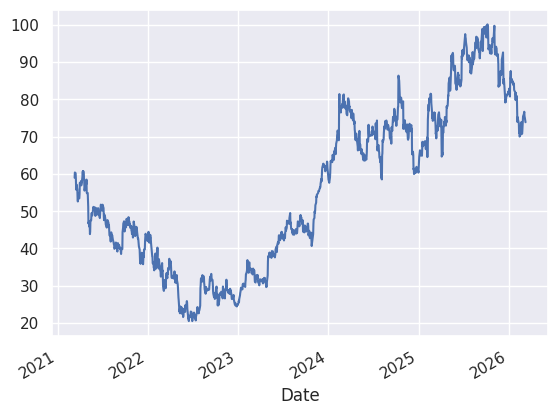

In [50]:
df.Close.plot() #notowania spółki

polecany kurs dla bardziej głębokich wyliczeń, typu średnia ruchoma, pęk średniej - Wprowadzenie do Data Science w języku Python Pandas

#Filtrowanie danych

In [51]:
df

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2021-03-11,58.80,59.480,58.220,58.95,17293752,58.875,NaN,NaN
2021-03-12,58.97,60.590,57.620,60.35,14839307,59.660,58.95,0.023749
2021-03-15,60.35,60.530,59.120,60.19,14993629,60.270,60.35,-0.002651
2021-03-16,59.99,61.020,58.380,58.85,12885725,59.420,60.19,-0.022263
2021-03-17,57.07,57.570,55.540,56.36,25509926,56.715,58.85,-0.042311
...,...,...,...,...,...,...,...,...
2026-03-03,74.50,77.305,74.020,76.36,21892515,75.430,75.95,0.005398
2026-03-04,75.87,77.040,75.013,76.65,19818516,76.260,76.36,0.003798
2026-03-05,76.59,78.250,75.135,75.44,17893964,76.015,76.65,-0.015786


In [52]:
df.Daily_Change > 0

,Daily_Change
Date,
2021-03-11,False
2021-03-12,True
2021-03-15,False
2021-03-16,False
2021-03-17,False
...,...
2026-03-03,True
2026-03-04,True
2026-03-05,False


In [53]:
df[df.Daily_Change > 0] #wycięcie - maska w nawiasie kwadratowym

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2021-03-12,58.97,60.590,57.620,60.35,14839307,59.660,58.95,0.023749
2021-03-19,55.48,57.180,54.340,57.08,17396297,56.280,55.69,0.024960
2021-03-25,52.00,54.280,51.800,53.89,13210740,52.945,52.57,0.025109
2021-03-26,54.41,55.250,53.520,54.71,13528233,54.560,53.89,0.015216
2021-03-30,52.99,54.120,52.640,53.46,9497186,53.225,53.35,0.002062
...,...,...,...,...,...,...,...,...
2026-02-26,73.01,76.100,72.830,74.80,22383431,73.905,72.83,0.027049
2026-02-27,73.90,75.780,73.658,75.42,20416029,74.660,74.80,0.008289
2026-03-02,73.50,76.495,73.150,75.95,25779070,74.725,75.42,0.007027


In [56]:
df_positive = df[df.Daily_Change > 0]
df_positive

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2021-03-12,58.97,60.590,57.620,60.35,14839307,59.660,58.95,0.023749
2021-03-19,55.48,57.180,54.340,57.08,17396297,56.280,55.69,0.024960
2021-03-25,52.00,54.280,51.800,53.89,13210740,52.945,52.57,0.025109
2021-03-26,54.41,55.250,53.520,54.71,13528233,54.560,53.89,0.015216
2021-03-30,52.99,54.120,52.640,53.46,9497186,53.225,53.35,0.002062
...,...,...,...,...,...,...,...,...
2026-02-26,73.01,76.100,72.830,74.80,22383431,73.905,72.83,0.027049
2026-02-27,73.90,75.780,73.658,75.42,20416029,74.660,74.80,0.008289
2026-03-02,73.50,76.495,73.150,75.95,25779070,74.725,75.42,0.007027


In [58]:
df_positive.Daily_Change.mean() #średnia dodatnia stopa zwrotu

np.float64(0.02153935403876853)

In [59]:
df_negative = df[df.Daily_Change < 0]
df_negative

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2021-03-15,60.35,60.53,59.120,60.19,14993629,60.270,60.35,-0.002651
2021-03-16,59.99,61.02,58.380,58.85,12885725,59.420,60.19,-0.022263
2021-03-17,57.07,57.57,55.540,56.36,25509926,56.715,58.85,-0.042311
2021-03-18,56.63,57.48,55.210,55.69,15742985,56.160,56.36,-0.011888
2021-03-22,57.25,57.61,55.470,55.69,14149412,56.470,57.08,-0.024352
...,...,...,...,...,...,...,...,...
2026-02-13,71.20,71.42,69.020,69.99,26526713,70.595,71.22,-0.017270
2026-02-23,72.99,73.11,70.150,70.72,22921600,71.855,73.86,-0.042513
2026-03-05,76.59,78.25,75.135,75.44,17893964,76.015,76.65,-0.015786


In [60]:
df_negative.Daily_Change.mean() #średnia ujemna stopa zwrotu

np.float64(-0.020036378069709853)

In [61]:
df.Close == df.High

,0
Date,
2021-03-11,False
2021-03-12,False
2021-03-15,False
2021-03-16,False
2021-03-17,False
...,...
2026-03-03,False
2026-03-04,False
2026-03-05,False


In [62]:
df[df.Close == df.High] #w ciągu danej sesji dane spółki zamknęły się na maksimum

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2022-11-30,27.8,29.14,27.64,29.14,18177028,28.47,27.76,0.049712


In [63]:
df[df.Close == df.Low] #w ciągu danej sesji dane spółki zamknęły się na minimum

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2021-12-31,42.53,43.12,41.93,41.93,13746893,42.230,42.66,-0.017112
2023-01-05,25.73,26.01,25.55,25.55,9942038,25.640,25.91,-0.013894
2023-05-16,37.93,38.15,37.44,37.44,21836864,37.685,38.14,-0.018353
2023-05-30,38.73,39.06,37.56,37.56,18143192,38.145,38.45,-0.023147
2025-07-24,91.14,93.61,90.87,90.87,23446209,91.005,89.94,0.010340
2025-08-27,96.50,96.95,95.33,95.33,11364308,95.915,96.53,-0.012431


In [65]:
df.index > '2025-01-01'

array([False, False, False, ...,  True,  True,  True])

In [66]:
df[df.index > '2025-01-01']

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2025-01-02,62.19,63.390,61.310,63.17,25899072,62.680,60.32,0.047248
2025-01-03,63.69,65.220,63.440,64.59,28553825,64.140,63.17,0.022479
2025-01-06,66.97,67.350,66.040,66.31,32980652,66.640,64.59,0.026630
2025-01-07,68.49,68.840,65.950,66.15,35347776,67.320,66.31,-0.002413
2025-01-08,66.40,66.680,64.120,64.91,24523299,65.655,66.15,-0.018745
...,...,...,...,...,...,...,...,...
2026-03-03,74.50,77.305,74.020,76.36,21892515,75.430,75.95,0.005398
2026-03-04,75.87,77.040,75.013,76.65,19818516,76.260,76.36,0.003798
2026-03-05,76.59,78.250,75.135,75.44,17893964,76.015,76.65,-0.015786


In [67]:
df[(df.index >= '2025-01-01') & (df.index < '2026-01-01')] #warunek łączony -> and = &, or = |

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2025-01-02,62.190,63.3900,61.3100,63.17,25899072,62.6800,60.32,0.047248
2025-01-03,63.690,65.2200,63.4400,64.59,28553825,64.1400,63.17,0.022479
2025-01-06,66.970,67.3500,66.0400,66.31,32980652,66.6400,64.59,0.026630
2025-01-07,68.490,68.8400,65.9500,66.15,35347776,67.3200,66.31,-0.002413
2025-01-08,66.400,66.6800,64.1200,64.91,24523299,65.6550,66.15,-0.018745
...,...,...,...,...,...,...,...,...
2025-12-24,81.010,81.4100,80.5800,81.15,4310663,81.0800,80.97,0.002223
2025-12-26,81.200,81.5000,80.6801,81.26,6741595,81.2300,81.15,0.001356
2025-12-29,80.910,82.1999,80.7850,81.50,12072642,81.2050,81.26,0.002953


In [68]:
df[(df.index < '2025-01-01') | (df.index >= '2026-01-01')]

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2021-03-11,58.80,59.480,58.220,58.95,17293752,58.875,NaN,NaN
2021-03-12,58.97,60.590,57.620,60.35,14839307,59.660,58.95,0.023749
2021-03-15,60.35,60.530,59.120,60.19,14993629,60.270,60.35,-0.002651
2021-03-16,59.99,61.020,58.380,58.85,12885725,59.420,60.19,-0.022263
2021-03-17,57.07,57.570,55.540,56.36,25509926,56.715,58.85,-0.042311
...,...,...,...,...,...,...,...,...
2026-03-03,74.50,77.305,74.020,76.36,21892515,75.430,75.95,0.005398
2026-03-04,75.87,77.040,75.013,76.65,19818516,76.260,76.36,0.003798
2026-03-05,76.59,78.250,75.135,75.44,17893964,76.015,76.65,-0.015786


In [69]:
df

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2021-03-11,58.80,59.480,58.220,58.95,17293752,58.875,NaN,NaN
2021-03-12,58.97,60.590,57.620,60.35,14839307,59.660,58.95,0.023749
2021-03-15,60.35,60.530,59.120,60.19,14993629,60.270,60.35,-0.002651
2021-03-16,59.99,61.020,58.380,58.85,12885725,59.420,60.19,-0.022263
2021-03-17,57.07,57.570,55.540,56.36,25509926,56.715,58.85,-0.042311
...,...,...,...,...,...,...,...,...
2026-03-03,74.50,77.305,74.020,76.36,21892515,75.430,75.95,0.005398
2026-03-04,75.87,77.040,75.013,76.65,19818516,76.260,76.36,0.003798
2026-03-05,76.59,78.250,75.135,75.44,17893964,76.015,76.65,-0.015786


In [70]:
df.index.month

Index([3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       ...
       2, 2, 2, 2, 3, 3, 3, 3, 3, 3],
      dtype='int32', name='Date', length=1254)

In [73]:
(df.index.month == 3) & (df.index.year == 2025)

array([False, False, False, ..., False, False, False])

In [74]:
df[(df.index.month == 3) & (df.index.year == 2025)]

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2025-03-03,77.1900,77.7400,73.6800,74.44,16999495,75.81500,76.01,-0.020655
2025-03-04,72.9300,76.6800,71.6000,75.26,24241234,74.09500,74.44,0.011016
2025-03-05,75.6500,76.9400,74.9300,76.48,13122294,76.06500,75.26,0.016210
2025-03-06,75.3150,77.2200,74.7254,74.96,16504911,75.13750,76.48,-0.019874
2025-03-07,74.0450,76.6996,73.7800,76.27,18610386,75.15750,74.96,0.017476
2025-03-10,74.7800,75.4900,71.9700,73.06,22120094,73.92000,76.27,-0.042087
2025-03-11,71.4400,74.2500,69.5700,70.65,26668190,71.04500,73.06,-0.032987
2025-03-12,72.3100,72.4200,69.5500,71.20,17315032,71.75500,70.65,0.007785
2025-03-13,71.7250,72.0000,69.3600,69.51,15272232,70.61750,71.20,-0.023736


In [75]:
df[df.index.day == 1]

,Open,High,Low,Close,Volume,Average,Close_shift,Daily_Change
Date,,,,,,,,
2021-04-01,55.610,57.6300,54.810,57.60,18703397,56.6050,54.51,0.056687
2021-06-01,51.620,51.6600,49.840,50.98,16583752,51.3000,50.83,0.002951
2021-07-01,50.880,51.6000,50.020,50.59,17732585,50.7350,50.12,0.009377
2021-09-01,39.980,41.6650,39.870,40.62,27788584,40.3000,39.14,0.037813
2021-10-01,45.915,47.2500,45.790,47.05,25428283,46.4825,44.80,0.050223
2021-11-01,44.070,45.0250,43.650,44.36,20983925,44.2150,43.82,0.012323
2021-12-01,39.450,39.5000,35.800,36.02,47369182,37.7350,38.00,-0.052105
2022-02-01,37.630,38.7050,37.200,38.61,19669916,38.1200,37.40,0.032353
2022-03-01,35.450,35.6000,33.650,33.89,31436210,34.6700,36.03,-0.059395
